In [1]:
import cv2
import numpy as np

In [ ]:
def save_image(image, filename):
    cv2.imwrite(filename, image)

def load_image(image_path):
    cv2_image = cv2.imread(image_path)
    if cv2_image is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
    return cv2_image

# Detect keypoints and compute descriptors using SIFT
def detect_and_compute_sift(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

# keypoint visualization
def draw_keypoints(image, keypoints):
    output_image = cv2.UMat(image)
    cv2.drawKeypoints(
        image,
        keypoints,
        output_image,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    return output_image.get()

# matching visualization
def draw_matches(image1, keypoints1, image2, keypoints2, matches):
    return cv2.drawMatches(
            image1,
            keypoints1,
            image2,
            keypoints2,
            matches,
            None, # type: ignore
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        ) # type: ignore

### PART 1: Image Capture and Feature Extraction


In [3]:
# Load images
image_1 = load_image("Images/Set1_1.jpeg")
image_2 = load_image("Images/Set1_2.jpeg")
image_3 = load_image("Images/Set2_1.jpeg")
image_4 = load_image("Images/Set2_2.jpeg")

# Detect Keypoints
output_images_1 = []
output_images_2 = []

keypoints1, descriptors1 = detect_and_compute_sift(image_1)
output_images_1.append(draw_keypoints(image_1, keypoints1))

keypoints2, descriptors2 = detect_and_compute_sift(image_2)
output_images_1.append(draw_keypoints(image_2, keypoints2))

keypoints3, descriptors3 = detect_and_compute_sift(image_3)
output_images_2.append(draw_keypoints(image_3, keypoints3))

keypoints4, descriptors4 = detect_and_compute_sift(image_4)
output_images_2.append(draw_keypoints(image_4, keypoints4))

# Resize outputs to the same height and display them side by side.
display_height = min(image.shape[0] for image in output_images_1)
resized_images1 = [
    cv2.resize(
        image,
        (int(image.shape[1] * display_height / image.shape[0]), display_height),
    )
    for image in output_images_1
]

display_height = min(image.shape[0] for image in output_images_2)
resized_images2 = [
    cv2.resize(
        image,
        (int(image.shape[1] * display_height / image.shape[0]), display_height),
    )
    for image in output_images_2
]

save_image(cv2.hconcat(resized_images1), "outputs/Set1_keypoints.jpg")
save_image(cv2.hconcat(resized_images2), "outputs/Set2_keypoints.jpg")

print("Keypoints in Image 1:", len(keypoints1))
print("Keypoints in Image 2:", len(keypoints2))
print("Keypoints in Image 3:", len(keypoints3))
print("Keypoints in Image 4:", len(keypoints4))

Keypoints in Image 1: 7460
Keypoints in Image 2: 3769
Keypoints in Image 3: 9081
Keypoints in Image 4: 17587


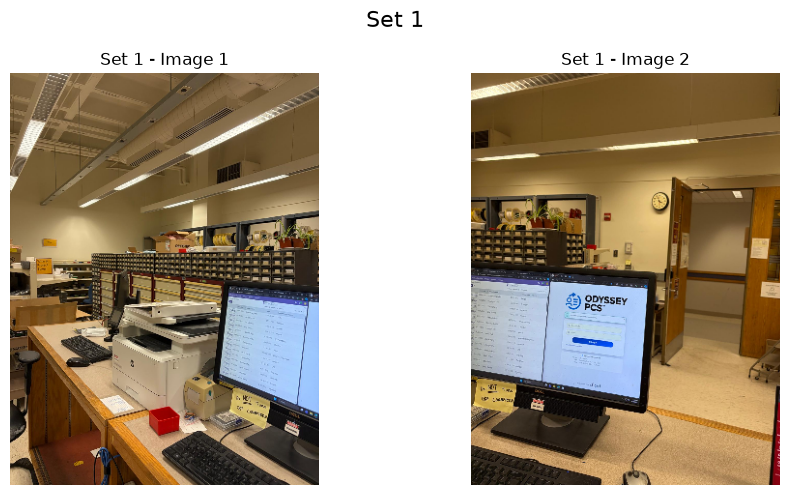

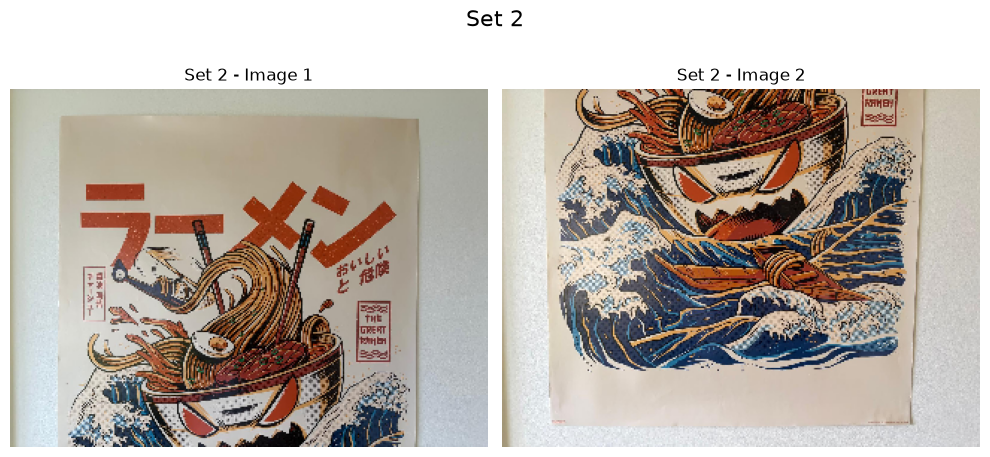

In [8]:
# Include both input sets as separate labeled thumbnail figures
import matplotlib.pyplot as plt


def make_thumbnail(image, width=320):
    height = int(image.shape[0] * width / image.shape[1])
    return cv2.resize(image, (width, height))


def display_set(title, images, labels):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(title, fontsize=16)

    for axis, image, label in zip(axes, images, labels):
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(label)
        axis.axis("off")

    fig.tight_layout()
    plt.show()


set1_thumbnails = [make_thumbnail(image_1), make_thumbnail(image_2)]
set2_thumbnails = [make_thumbnail(image_3), make_thumbnail(image_4)]

display_set(
    "Set 1",
    set1_thumbnails,
    ["Set 1 - Image 1", "Set 1 - Image 2"],
)
display_set(
    "Set 2",
    set2_thumbnails,
    ["Set 2 - Image 1", "Set 2 - Image 2"],
)


### PART 2: Descriptor Matching


In [10]:
# descriptor matching
def match_descriptors(descriptors1, descriptors2):
    if descriptors1 is None or descriptors2 is None or len(descriptors2) < 2:
        return []

    descriptors1 = np.asarray(descriptors1, dtype=np.float32)
    descriptors2 = np.asarray(descriptors2, dtype=np.float32)
    matches = []

    for query_index, descriptor in enumerate(descriptors1):
        distances = np.sum((descriptors2 - descriptor) ** 2, axis=1)
        nearest_indices = np.argsort(distances)[:2]
        first_index, second_index = nearest_indices
        matches.append((
            cv2.DMatch(
                query_index,
                int(first_index),
                0,
                float(np.sqrt(distances[first_index])),
            ),
            cv2.DMatch(
                query_index,
                int(second_index),
                0,
                float(np.sqrt(distances[second_index])),
            ),
        ))

    return matches

def ratio_test(matches, ratio_threshold=0.7):
    return [
        first_match
        for first_match, second_match in matches
        if first_match.distance < ratio_threshold * second_match.distance
    ]

In [12]:
# Draw matches

#Set1
nearest_matches = match_descriptors(descriptors1, descriptors2)
candidate_matches = [first_match for first_match, _ in nearest_matches]
matches1 = ratio_test(nearest_matches, ratio_threshold=0.7)

print("Candidate matches Set1:", len(candidate_matches))
print("Matches after ratio test Set1:", len(matches1))

matched_image_before = draw_matches(
    image_1, keypoints1, image_2, keypoints2, candidate_matches
)
matched_image = draw_matches(image_1, keypoints1, image_2, keypoints2, matches1)
save_image(matched_image_before, "outputs/Set1_matches_before_ratio.jpg")
save_image(matched_image, "outputs/Set1_matches_after_ratio.jpg")

#Set2
nearest_matches = match_descriptors(descriptors3, descriptors4)
candidate_matches = [first_match for first_match, _ in nearest_matches]
matches2 = ratio_test(nearest_matches) 

print("Candidate matches Set2:", len(candidate_matches))
print("Matches after ratio test Set2:", len(matches2))

matched_image_before = draw_matches(
    image_3, keypoints3, image_4, keypoints4, candidate_matches
)
matched_image = draw_matches(image_3, keypoints3, image_4, keypoints4, matches2)
save_image(matched_image_before, "outputs/Set2_matches_before_ratio.jpg")
save_image(matched_image, "outputs/Set2_matches_after_ratio.jpg")


Candidate matches Set1: 7460
Matches after ratio test Set1: 518
Candidate matches Set2: 9081
Matches after ratio test Set2: 2464


### PART 3: Homography Estimation


In [11]:
def project(H, pts):           # matrix multiply, then homogenous divide
    ph = np.column_stack([pts, np.ones(len(pts))]) @ H.T
    return ph[:, :2] / ph[:, 2:3]

def mean_err(H, src, dst):
    return np.linalg.norm(project(H, src) - dst, axis=1).mean()

def normalize_points(points):
    points = np.asarray(points, dtype=np.float64)
    center = points.mean(axis=0)
    distances = np.linalg.norm(points - center, axis=1)
    mean_distance = distances.mean()
    if mean_distance == 0:
        raise ValueError("Cannot normalize coincident points.")

    scale = np.sqrt(2.0) / mean_distance
    transform = np.array([
        [scale, 0.0, -scale * center[0]],
        [0.0, scale, -scale * center[1]],
        [0.0, 0.0, 1.0],
    ])
    homogeneous = np.column_stack([points, np.ones(len(points))])
    normalized = (transform @ homogeneous.T).T
    return normalized[:, :2], transform

def find_homography(src, dst):
    if len(src) != len(dst) or len(src) < 4:
        raise ValueError("Homography estimation requires at least four pairs.")

    normalized_src, src_transform = normalize_points(src)
    normalized_dst, dst_transform = normalize_points(dst)

    # Solve DLT in normalized coordinates for numerical stability.
    A = []
    for (x, y), (u, v) in zip(normalized_src, normalized_dst):
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])

    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    normalized_H = Vt[-1].reshape(3, 3)

    H = np.linalg.inv(dst_transform) @ normalized_H @ src_transform
    return H / H[2, 2]

H_true = np.array([[ 0.9,   0.1,  40.],
                [-0.05,  1.1,  20.],
                [ 3e-4, -2e-4,  1. ]]) # nonzero bottom row: real perspective

src = np.array([[50., 40.], [600., 70.], [560., 430.], [80., 400.]])
dst = project(H_true, src)          # (88.38, 61.07)  (503.43, 57.46) ...
H = find_homography(src, dst)       # your HW1 code (DLT) goes here 
print("Exact 4-point mean error:", f"{mean_err(H, src, dst):.2e}", "px")

rng = np.random.default_rng(0)
src = rng.uniform([0, 0], [640, 480], size=(20, 2))   # 20 points over the frame
dest = project(H_true, src)

H = find_homography(src, dest)
print("Exact 20-point mean error:", f"{mean_err(H, src, dest):.2e}", "px")

noisy = dest + rng.normal(0, 0.5, dest.shape)     # sigma = 0.5 px
H = find_homography(src, noisy)

print("Noisy fit error:", f"{mean_err(H, src, noisy):.2f}", "px")
print("Noisy fit error against clean points:", f"{mean_err(H, src, dest):.2f}", "px")


Exact 4-point mean error: 1.30e-13 px
Exact 20-point mean error: 1.17e-13 px
Noisy fit error: 0.62 px
Noisy fit error against clean points: 0.30 px


### PART 4: Basic Robust Estimation with RANSAC


In [13]:
def non_degenerate(points):
    a, b, c, d = points
    ab = b - a
    ac = c - a
    ad = d - a
    area_abc = ab[0] * ac[1] - ab[1] * ac[0]
    area_abd = ab[0] * ad[1] - ab[1] * ad[0]
    return abs(area_abc) > 1e-6 or abs(area_abd) > 1e-6

def ransac(src, dst, threshold=5.0, iterations=1000):
    rng = np.random.default_rng(0)
    best_H = None
    best_mask = None
    best_count = 0

    for _ in range(iterations):
        sample_indices = rng.choice(len(src), 4, replace=False)
        sample_src = src[sample_indices]
        sample_dst = dst[sample_indices]

        if not non_degenerate(sample_src) or not non_degenerate(sample_dst):
            continue

        candidate_H = find_homography(sample_src, sample_dst)
        errors = np.linalg.norm(project(candidate_H, src) - dst, axis=1)
        
        inlier_mask = errors < threshold
        inlier_count = int(inlier_mask.sum())

        if inlier_count > best_count:
            best_H = candidate_H
            best_count = inlier_count
            best_mask = inlier_mask

    return best_H, best_mask

In [14]:
# Set 1
src_points = np.float64([keypoints1[m.queryIdx].pt for m in matches1]) # type: ignore
dst_points = np.float64([keypoints2[m.trainIdx].pt for m in matches1]) # type: ignore

H_before_refit1, inlier_mask = ransac(src_points, dst_points)
H_after_refit1 = find_homography(src_points[inlier_mask], dst_points[inlier_mask])

before_error = np.linalg.norm(
    project(H_before_refit1, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

after_error = np.linalg.norm(
    project(H_after_refit1, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()
print("SET 1")
print("Total matches:", len(matches1))
print("RANSAC inliers:", int(inlier_mask.sum()))
print("Inlier ratio:", f"{inlier_mask.mean():.2f}")
print("Mean inlier error before refit:", f"{before_error:.2f}", "px")
print("Mean inlier error after refit:", f"{after_error:.2f}", "px")

outlier_matches1 = [m for m, is_inlier in zip(matches1, inlier_mask) if not is_inlier]
inlier_matches1 = [m for m, is_inlier in zip(matches1, inlier_mask) if is_inlier]

ransac_image1 = cv2.drawMatches(
    image_1, keypoints1, image_2, keypoints2, tuple(outlier_matches1), None, # type: ignore
    (0, 0, 255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
) # type: ignore

for match in inlier_matches1:
    point1 = tuple(np.round(keypoints1[match.queryIdx].pt).astype(int))
    point2 = tuple(
        np.round(keypoints2[match.trainIdx].pt).astype(int)
        + np.array([image_1.shape[1], 0])
    )
    cv2.line(ransac_image1, point1, point2, (0, 255, 0), 1, cv2.LINE_AA)

save_image(ransac_image1, "outputs/Set1_ransac_matches.jpg")

# Set 2
src_points = np.float64([keypoints3[m.queryIdx].pt for m in matches2]) # type: ignore
dst_points = np.float64([keypoints4[m.trainIdx].pt for m in matches2]) # type: ignore

H_before_refit2, inlier_mask = ransac(src_points, dst_points)
H_after_refit2 = find_homography(src_points[inlier_mask], dst_points[inlier_mask])

before_error = np.linalg.norm(
    project(H_before_refit2, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

after_error = np.linalg.norm(
    project(H_after_refit2, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

print()
print("SET 2")
print("Total matches:", len(matches2))
print("RANSAC inliers:", int(inlier_mask.sum()))
print("Inlier ratio:", f"{inlier_mask.mean():.2f}")
print("Mean inlier error before refit:", f"{before_error:.2f}", "px")
print("Mean inlier error after refit:", f"{after_error:.2f}", "px")

outlier_matches2 = [m for m, is_inlier in zip(matches2, inlier_mask) if not is_inlier]
inlier_matches2 = [m for m, is_inlier in zip(matches2, inlier_mask) if is_inlier]

ransac_image2 = cv2.drawMatches(
    image_3, keypoints3, image_4, keypoints4, tuple(outlier_matches2), None, # type: ignore
    (0, 0, 255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
) # type: ignore

for match in inlier_matches2:
    point1 = tuple(np.round(keypoints3[match.queryIdx].pt).astype(int))
    point2 = tuple(
        np.round(keypoints4[match.trainIdx].pt).astype(int)
        + np.array([image_3.shape[1], 0])
    )
    cv2.line(ransac_image2, point1, point2, (0, 255, 0), 1, cv2.LINE_AA)

save_image(ransac_image2, "outputs/Set2_ransac_matches.jpg")


/tmp/ipykernel_3094/2440212115.py:3: RuntimeWarning: divide by zero encountered in divide
  return ph[:, :2] / ph[:, 2:3]
/tmp/ipykernel_3094/2440212115.py:3: RuntimeWarning: invalid value encountered in divide
  return ph[:, :2] / ph[:, 2:3]


SET 1
Total matches: 518
RANSAC inliers: 187
Inlier ratio: 0.36
Mean inlier error before refit: 1.48 px
Mean inlier error after refit: 0.87 px

SET 2
Total matches: 2464
RANSAC inliers: 2316
Inlier ratio: 0.94
Mean inlier error before refit: 1.72 px
Mean inlier error after refit: 1.07 px


### PART 5: Warping and Compositing


In [32]:
def warp_image(image, image_to_canvas, canvas_shape):
    canvas_height, canvas_width = canvas_shape
    rows, cols = np.indices((canvas_height, canvas_width), dtype=np.float64)

    canvas_points = np.column_stack([cols.ravel(), rows.ravel(), np.ones(rows.size)])

    source = (np.linalg.inv(image_to_canvas) @ canvas_points.T).T
    source = source[:, :2] / source[:, 2:3]
    source_x = source[:, 0].reshape(canvas_shape).astype(np.float32)
    source_y = source[:, 1].reshape(canvas_shape).astype(np.float32)

    valid = (
        np.isfinite(source_x)
        & np.isfinite(source_y)
        & (source_x >= 0)
        & (source_x <= image.shape[1] - 1)
        & (source_y >= 0)
        & (source_y <= image.shape[0] - 1)
    )

    warped = cv2.remap(
        image,
        source_x,
        source_y,
        cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
    )

    return warped, valid

def transform_corners(corners, image_to_canvas):
    homogeneous = np.column_stack([corners, np.ones(len(corners))])
    transformed = (image_to_canvas @ homogeneous.T).T
    return transformed[:, :2] / transformed[:, 2:3]

In [33]:
# SYNTHETIC TEST

# Synthetic warp checks with identifiable landmarks.
test_image = np.zeros((80, 100, 3), dtype=np.uint8)
landmarks = np.array([[20, 20], [70, 25], [35, 60]], dtype=np.float64)

for x, y in landmarks.astype(int):
    cv2.rectangle(test_image, (x - 2, y - 2), (x + 2, y + 2), (255, 255, 255), -1)

def check_warp(name, transform, offset):
    image_to_canvas = offset @ transform
    warped, valid = warp_image(test_image, image_to_canvas, (140, 180))
    expected = project(image_to_canvas, landmarks)

    for x, y in np.round(expected).astype(int):
        patch = warped[max(0, y - 2):y + 3, max(0, x - 2):x + 3]

        if not valid[y, x] or patch.max() < 200:
            raise AssertionError(f"{name} landmark check failed at {(x, y)}")
        
    save_image(warped, f"outputs/synthetic_warp_{name}.png")

    print(f"Synthetic {name} transform:\n", transform)
    print(f"Synthetic {name} landmarks verified at:", expected.astype(int).tolist())

test_offset = np.array([
    [1.0, 0.0, 30.0],
    [0.0, 1.0, 25.0],
    [0.0, 0.0, 1.0],
])

check_warp(
    "translation",
    np.array([[1.0, 0.0, -20.0], [0.0, 1.0, -15.0], [0.0, 0.0, 1.0]]),
    test_offset,
)
check_warp(
    "scale",
    np.array([[1.4, 0.0, 0.0], [0.0, 1.4, 0.0], [0.0, 0.0, 1.0]]),
    test_offset,
)

save_image(test_image, "outputs/synthetic_warp_input.png")

Synthetic translation transform:
 [[  1.   0. -20.]
 [  0.   1. -15.]
 [  0.   0.   1.]]
Synthetic translation landmarks verified at: [[30, 30], [80, 35], [45, 70]]
Synthetic scale transform:
 [[1.4 0.  0. ]
 [0.  1.4 0. ]
 [0.  0.  1. ]]
Synthetic scale landmarks verified at: [[58, 53], [128, 60], [79, 109]]


In [34]:
# SET 1 PANORAMA
image_2_to_image_1 = np.linalg.inv(H_after_refit1)

corners_1 = np.array([
    [0, 0],
    [image_1.shape[1] - 1, 0],
    [image_1.shape[1] - 1, image_1.shape[0] - 1],
    [0, image_1.shape[0] - 1],
], dtype=np.float64)

corners_2 = np.array([
    [0, 0],
    [image_2.shape[1] - 1, 0],
    [image_2.shape[1] - 1, image_2.shape[0] - 1],
    [0, image_2.shape[0] - 1],
], dtype=np.float64)

transformed_corners1 = np.vstack([
    corners_1,
    project(image_2_to_image_1, corners_2),
])

minimum1 = np.floor(transformed_corners1.min(axis=0)).astype(int)
maximum1 = np.ceil(transformed_corners1.max(axis=0)).astype(int)

offset1 = np.array([
    [1.0, 0.0, -minimum1[0]],
    [0.0, 1.0, -minimum1[1]],
    [0.0, 0.0, 1.0],
])

canvas_shape1 = (
    int(maximum1[1] - minimum1[1] + 1),
    int(maximum1[0] - minimum1[0] + 1),
)

warped_1, valid_1 = warp_image(image_1, offset1, canvas_shape1)
warped_2, valid_2 = warp_image(image_2, offset1 @ image_2_to_image_1, canvas_shape1)

panorama1 = np.zeros_like(warped_1)
panorama1[valid_1] = warped_1[valid_1]
panorama1[valid_2] = warped_2[valid_2]

save_image(panorama1, "outputs/Set1_panorama.jpg")
print("Panorama 1 canvas:", canvas_shape1[1], "x", canvas_shape1[0])

boundary_image1 = panorama1.copy()
boundary_1 = np.round(transform_corners(corners_1, offset1)).astype(np.int32)
boundary_2 = np.round(
    transform_corners(corners_2, offset1 @ image_2_to_image_1)
).astype(np.int32)

cv2.polylines(boundary_image1, [boundary_1], True, (255, 0, 0), 6)
cv2.polylines(boundary_image1, [boundary_2], True, (0, 255, 255), 6)

save_image(boundary_image1, "outputs/Set1_panorama_annotated.jpg")

Panorama 1 canvas: 3139 x 3064


In [35]:
# SET 2 PANORAMA
image_4_to_image_3 = np.linalg.inv(H_after_refit2)

corners_3 = np.array([
    [0, 0],
    [image_3.shape[1] - 1, 0],
    [image_3.shape[1] - 1, image_3.shape[0] - 1],
    [0, image_3.shape[0] - 1],
], dtype=np.float64)    

corners_4 = np.array([
    [0, 0],
    [image_4.shape[1] - 1, 0],
    [image_4.shape[1] - 1, image_4.shape[0] - 1],
    [0, image_4.shape[0] - 1],
], dtype=np.float64)

transformed_corners2 = np.vstack([
    corners_3,
    project(image_4_to_image_3, corners_4),
])

minimum2 = np.floor(transformed_corners2.min(axis=0)).astype(int)
maximum2 = np.ceil(transformed_corners2.max(axis=0)).astype(int)

offset2 = np.array([
    [1.0, 0.0, -minimum2[0]],
    [0.0, 1.0, -minimum2[1]],
    [0.0, 0.0, 1.0],
])

canvas_shape2 = (
    int(maximum2[1] - minimum2[1] + 1),
    int(maximum2[0] - minimum2[0] + 1),
)

warped_3, valid_3 = warp_image(image_3, offset2, canvas_shape2)
warped_4, valid_4 = warp_image(image_4, offset2 @ image_4_to_image_3, canvas_shape2)

panorama2 = np.zeros_like(warped_3)
panorama2[valid_3] = warped_3[valid_3]
panorama2[valid_4] = warped_4[valid_4]

save_image(panorama2, "outputs/Set2_panorama.jpg")
print("Panorama 2 canvas:", canvas_shape2[1], "x", canvas_shape2[0])

boundary_image2 = panorama2.copy()
boundary_3 = np.round(transform_corners(corners_3, offset2)).astype(np.int32)
boundary_4 = np.round(
    transform_corners(corners_4, offset2 @ image_4_to_image_3)
).astype(np.int32)

cv2.polylines(boundary_image2, [boundary_3], True, (255, 0, 0), 6)
cv2.polylines(boundary_image2, [boundary_4], True, (0, 255, 255), 6)

save_image(boundary_image2, "outputs/Set2_panorama_annotated.jpg")

Panorama 2 canvas: 1605 x 1981


###
